---
date: "2026-05-09"
date-modified: last-modified
format:
  html:
    toc: true
---

# 1. Cumulative Distribution Functions (CDF)

While [Probability Mass Functions](random-variables.ipynb#the-probability-mass-function-pmf) (PMFs) define the probability of discrete points, Cumulative Distribution Functions describe the accumulation of probability up to a certain threshold. Crucially, unlike PMFs, CDFs exist for *all* random variables—both discrete and continuous.

**Definition:** The Cumulative Distribution Function (CDF) of a random variable $X$ is the function $F_X$ evaluated as:

$$F_X(x) = P(X \le x)$$

For discrete random variables, the CDF visually forms a staircase. The flat, horizontal regions correspond to ranges where no probability mass exists. The function jumps vertically exactly at the support values of $X$. The height of the jump at any point $x$ is exactly equal to the PMF probability $P(X=x)$. To evaluate the CDF at a point, we simply sum the PMF over all values less than or equal to that point.

## 1.1 Properties of Valid CDFs

**Theorem (Valid CDFs):** Any valid CDF $F(x)$ must satisfy three strict mathematical criteria:

1. **Increasing:** If $x_1 \le x_2$, then $F(x_1) \le F(x_2)$.
2. **Right-Continuous:** The function is continuous from the right. At any jump $a$, $F(a) = \lim_{x \to a^+} F(x)$.
3. **Boundary Limits:** $\lim_{x \to -\infty} F(x) = 0$ and $\lim_{x \to \infty} F(x) = 1$.

**Proof:**

1. Let $x_1 \le x_2$. The event $\{X \le x_1\}$ is a strict subset of the event $\{X \le x_2\}$. By the axioms of probability, the probability of a subset cannot exceed the probability of the superset. Thus, $P(X \le x_1) \le P(X \le x_2)$.
2. For a discrete, integer-valued variable, $P(X \le 4.9) = P(X \le 4)$ because $X$ cannot physically take values between $4$ and $4.9$. Therefore, $F(a+\epsilon) = F(a)$ for small enough $\epsilon > 0$, proving the function remains flat immediately to the right of a jump, ensuring right-continuity.
3. As $x \to -\infty$, the event $\{X \le x\}$ evaluates to 0. As $x \to \infty$, the event encompasses the entire sample space, which sums the entire PMF to $1$. $\square$

## 1.2 Static Visualization

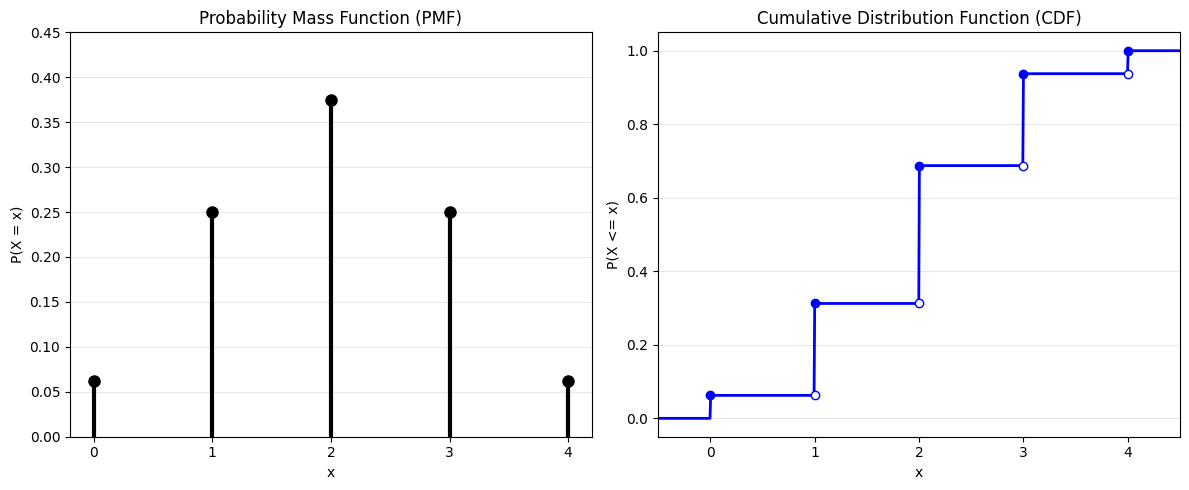

In [1]:
#| label: fig-pmf-cdf
#| fig-cap: "The relationship between a PMF and a CDF for a Binomial variable."

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

n, p = 4, 0.5
x_support = np.arange(0, n + 1)
pmf = binom.pmf(x_support, n, p)

# Create a dense array of x values to show the step nature of the CDF clearly
x_dense = np.linspace(-1, 5, 1000)
cdf_dense = binom.cdf(x_dense, n, p)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot PMF
ax1.vlines(x_support, 0, pmf, colors='black', lw=3)
ax1.plot(x_support, pmf, 'ko', markersize=8)
ax1.set_title("Probability Mass Function (PMF)")
ax1.set_xlabel("x")
ax1.set_ylabel("P(X = x)")
ax1.set_ylim(0, 0.45)
ax1.set_xticks(x_support)
ax1.grid(axis='y', alpha=0.3)

# Plot CDF
ax2.plot(x_dense, cdf_dense, color='blue', lw=2)
# Add open and closed dots to show right-continuity
for val in x_support:
    ax2.plot(val, binom.cdf(val, n, p), 'bo', markersize=6) # Closed dot
    if val > 0:
        ax2.plot(val, binom.cdf(val-1, n, p), 'wo', markeredgecolor='blue', markersize=6) # Open dot

ax2.set_title("Cumulative Distribution Function (CDF)")
ax2.set_xlabel("x")
ax2.set_ylabel("P(X <= x)")
ax2.set_ylim(-0.05, 1.05)
ax2.set_xlim(-0.5, 4.5)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()